## Analysis

In [3]:
from wilson.dataanalysis import *
import matplotlib.pyplot as plt
%matplotlib inline
from wilson.spectrum_generator import make_name, make_texts4fig

np.set_printoptions(precision=4)
import os

### 0. Data from DB: Preparing data for 1 spectrum (general, and DB)

In [51]:
log10=True
w1mw2=False
broad_factor_rc=10.

# terms_selection = [0, 1], [0, 1, 2, 3, 4, 5]
terms_selection = [0, 1], [0,]

regions = {1: ((1080., 2950., 10.), (2289., 5650., 10.)),
           2: ((2526.813, 2860., 10.), (5210., 5550., 10.)),
           3: ((2645., 2785., 10.), (3825., 4625., 10.)),
           4: ((680., 1750., 10.), (1509., 4350., 10.)),
           5: ((680., 1750., 10.), (1509., 3050., 10.))}

# template
settings_here = {'electrical': None, 'mechanical': None,
                 'Gamma_rc': broad_factor_rc, 'region': 2,
                 'font_dict': {'size': 18}, 'figsize': (12, 15), 'norm_max': 1e11}

spectra_dict = {"software": [], "code": [], "method": [], "basis_set": [],
                "el+mech max": [], "el max": [], "mech max": []}

other = {'regions': regions, 'terms_selection': terms_selection, 'w1mw2': False, 'log10': True}

from wilson.spectrum import getting_files_DB

dataframe_gaussian = getting_files_DB("gaussian")
print(dataframe_gaussian)
method_basis = dataframe_gaussian[(dataframe_gaussian['code'] == 'FORM') & (dataframe_gaussian['method'] != 'PBE0')][["code", "method", "basis_set"]]
tuples_method_basis = [(row['code'], row['method'], row['basis_set']) for index, row in method_basis.iterrows()]
print(tuples_method_basis)

    code method                basis_set                                                                                           g16_3quanta_full
0   FORM     HF                  cc_pVDZ                   /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVDZ/g16_inputFull_3q.out
1   FORM     HF             cc_pVDZ_VPT2              /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVDZ_VPT2/g16_inputFull_3q.out
2   FORM     HF                  cc_pVTZ                   /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVTZ/g16_inputFull_3q.out
3   FORM     HF                  cc_pVQZ                   /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVQZ/g16_inputFull_3q.out
4   FORM     HF             cc_pVQZ_VPT2              /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVQZ_VPT2/g16_inputFull_3q.out
5   FORM     HF                   STO_3G                   /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/

### 1. Mech Anh spectrum: Making 1 spectrum (_mechanical_ anharmonicity only)
Some $\omega_1$ and $\omega_2$ points where there are resonances (see below - 4.).
```
omega1 = [1185.288, 1247.878, 1501.586]
omega2 = [2687.219, 2491.481, 2364.564]
```


Used vibrational energy levels:
 harmonic? - False
{('0',): 2726.813, ('1',): 1794.54, ('2',): 1501.586, ('3',): 1185.288, ('4',): 2682.765, ('5',): 1247.878, ('0', '0'): 5390.225, ('0', '0', '0'): 7990.237, ('1', '1'): 3570.468, ('1', '1', '1'): 5327.784, ('2', '2'): 3004.865, ('2', '2', '2'): 4509.837, ('3', '3'): 2364.564, ('3', '3', '3'): 3537.828, ('4', '4'): 5428.69, ('4', '4', '4'): 8032.189, ('5', '5'): 2491.481, ('5', '5', '5'): 3730.809, ('0', '1'): 4522.216, ('0', '1', '1'): 6299.008, ('0', '0', '1'): 7186.492, ('0', '2'): 4197.002, ('0', '2', '2'): 5668.884, ('0', '0', '2'): 6829.018, ('1', '2'): 3290.38, ('1', '2', '2'): 4787.912, ('1', '1', '2'): 5060.561, ('0', '1', '2'): 5986.659, ('0', '3'): 3905.476, ('0', '3', '3'): 5078.128, ('0', '0', '3'): 6562.264, ('1', '3'): 2974.691, ('1', '3', '3'): 4148.83, ('1', '1', '3'): 4745.482, ('0', '1', '3'): 5695.743, ('2', '3'): 2687.219, ('2', '3', '3'): 3866.839, ('2', '2', '3'): 4190.842, ('0', '2', '3'): 5376.01, ('1', '2', '3

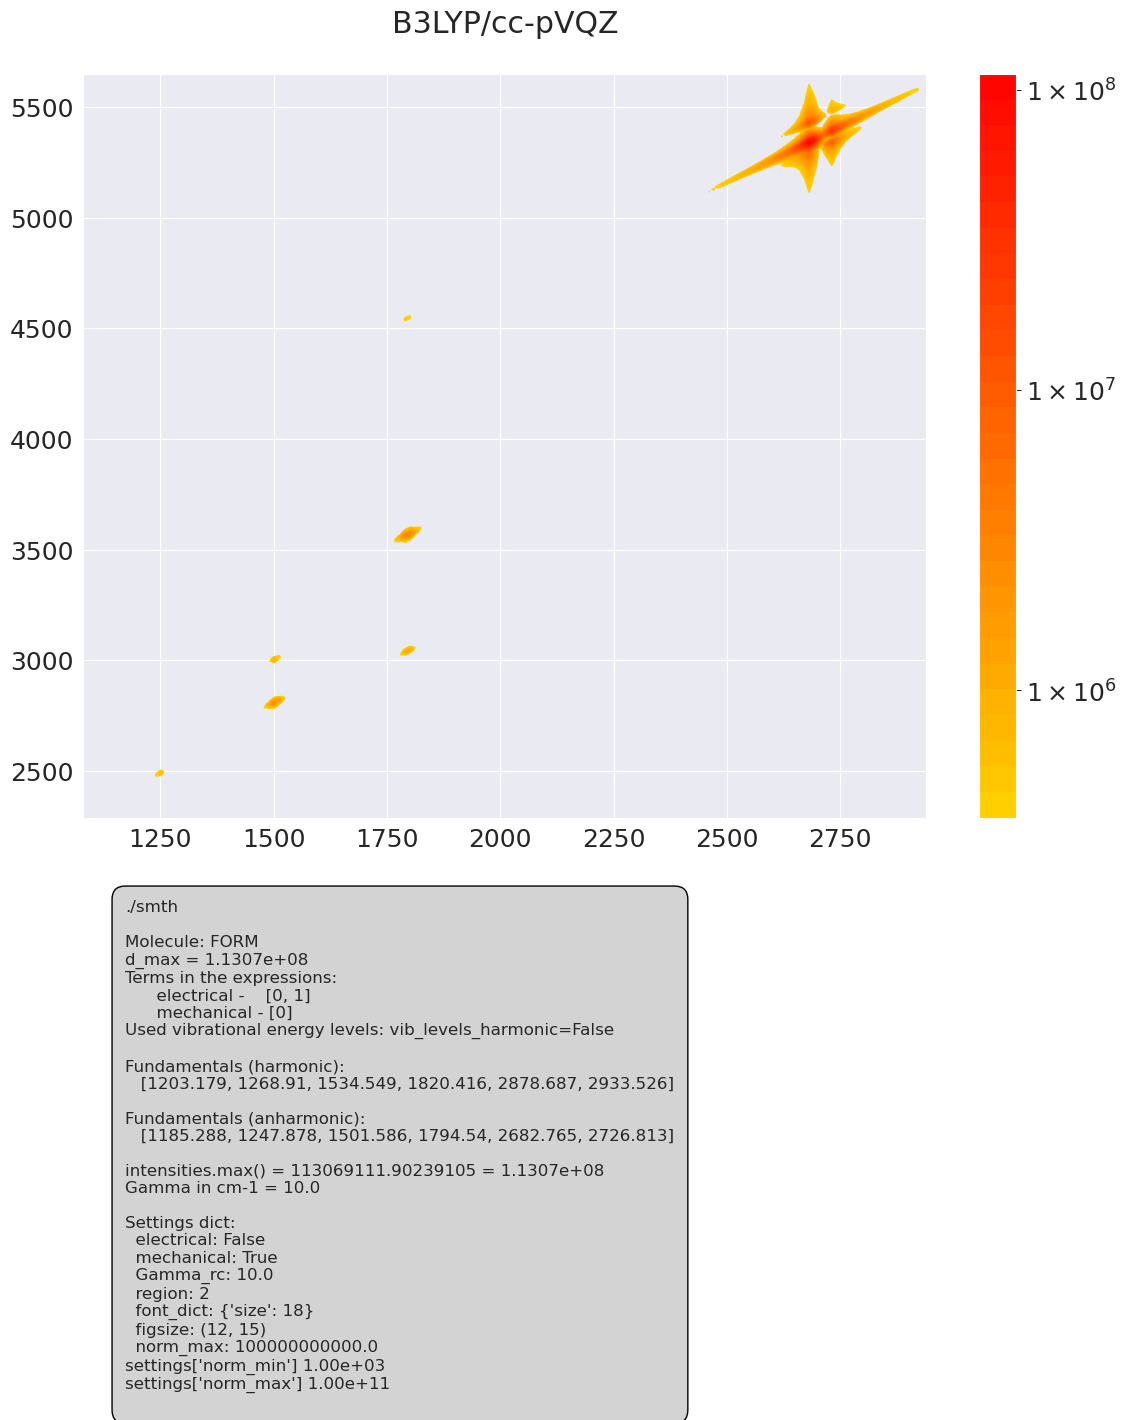

In [52]:
# selection of the spectrum
# datain = spectrum.make_DatainputDict('gaussian', ('FORM', 'B3LYP', 'aug_cc_pVTZ'))
datain = spectrum.make_DatainputDict('gaussian', ('FORM', 'B3LYP', 'cc_pVQZ'))
# list_figs = [(True, False), (False, True), (True, True)]
list_figs = [(False, True)]
region = 1
omega1 = np.arange(*regions[region][0])
omega2 = np.arange(*regions[region][1])
# omega1 = [1185.288, 1247.878, 1501.586]
# omega2 = [2687.219, 2491.481, 2364.564]

for s in list_figs:
    settings_here['electrical'] = s[0]
    settings_here['mechanical'] = s[1]
    vibEL=False
    directory='./smth'
    
    region = settings_here['region']
    Gamma_rc = settings_here['Gamma_rc']
    el_bool = settings_here['electrical']
    mech_bool = settings_here['mechanical']

    computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, vib_levels_harmonic=vibEL)
    computedSpectrum.addTerms(*terms_selection)
    print(computedSpectrum.all_states)
    # print(computedSpectrum.tensor_3d.T)
    Gamma = spectrum.rec_cm2rec_s(Gamma_rc)
    # sec_hypol_data, savedict = computedSpectrum.intensity(Gamma, {}, el=el_bool, mech=mech_bool)
    
    sec_hypol_data = 0
    if settings_here['electrical']:
        sec_hypol_data += computedSpectrum.intensity_electrical(Gamma)
    
    if settings_here['mechanical']:
        mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical(Gamma)
        template_array = np.full(mechall.shape, -0.+0.j, dtype=complex)
        sec_hypol_data += mechall
    
    name = make_name(datain, vibEL, settings_here, other, directory)
    artist = spectrum.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
    title_on_top, text_under_the_figure = make_texts4fig(datain, computedSpectrum, artist, settings_here, other, directory)
    fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                    text_under_the_figure=text_under_the_figure, to_save=False)
    plt.show()

## Small grid, points at resonances


Used vibrational energy levels:
 harmonic? - False

Execution time - mechanical: 0.14104437828063965 seconds
Mechanical anharmonicities are calculated
130485570.01931219 [2682.765 5345.29 ]
26953202.272499748 [2726.813 5390.225]
[[1.7779e+05 9.1214e+04 2.4391e+04 1.3393e+04 7.5791e+03]
 [3.4351e+06 1.3049e+08 3.1932e+06 1.1942e+07 2.1087e+06]
 [7.5229e+05 8.4957e+06 2.6953e+07 2.2078e+06 6.9140e+05]
 [1.5638e+04 4.4149e+04 1.5662e+05 1.5865e+05 4.9875e+05]
 [6.4050e+03 1.4719e+04 3.3927e+04 1.2650e+05 7.0708e+05]]
(11410.063147447845+544.0854625559564j) [2682.765 5345.29 ]
[[ -376.2395 +190.3401j  -276.8584 +120.6808j  -153.3226  +29.7201j  -114.2534  +18.4231j   -86.19    +12.2646j]
 [  603.5999-1752.3598j 11410.0631 +544.0855j   480.4968+1721.1261j  3171.0718+1373.5919j    77.9945+1450.0266j]
 [ -149.0756 -854.4415j  2692.2786-1116.8579j  4891.9621-1738.364j    773.676 +1268.568j    763.6601 +328.9789j]
 [ -123.2141  -21.3628j  -205.1917  -45.2263j  -371.1623 -137.3272j  -233.8849 -

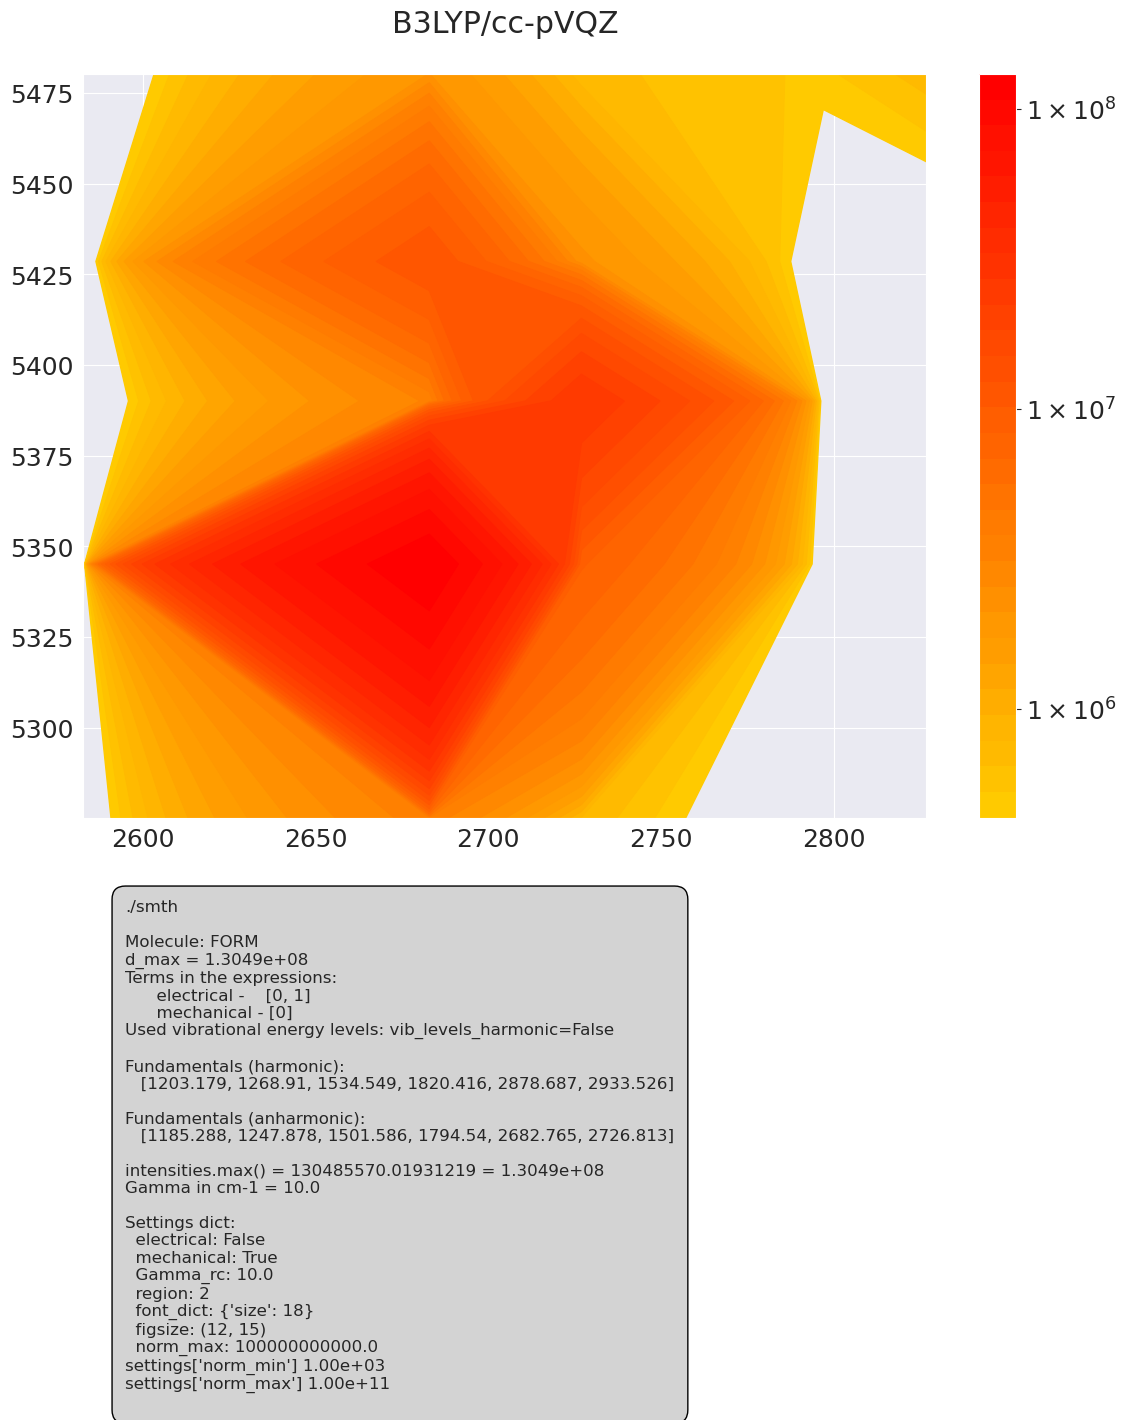

In [42]:
# selection of the spectrum
datain = spectrum.make_DatainputDict('gaussian', ('FORM', 'B3LYP', 'cc_pVQZ'))
# list_figs = [(True, False), (False, True), (True, True)]
list_figs = [(False, True)]
region = 2
# omega1 = np.arange(*regions[region][0])
# omega2 = np.arange(*regions[region][1])
omega1 = [2582.765, 2682.765, 2726.813, 2796.813, 2826.813]
omega2 = [5275.290, 5345.290, 5390.225, 5428.690, 5480.225]

for s in list_figs:
    settings_here['electrical'] = s[0]
    settings_here['mechanical'] = s[1]
    vibEL=False
    directory='./smth'
    
    region = settings_here['region']
    Gamma_rc = settings_here['Gamma_rc']
    el_bool = settings_here['electrical']
    mech_bool = settings_here['mechanical']

    computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, vib_levels_harmonic=vibEL)
    computedSpectrum.addTerms(*terms_selection)
    
    # positions = np.vstack([computedSpectrum.w1_mesh.ravel(), computedSpectrum.w2_mesh.ravel()])
    coordinate_grid = np.array([computedSpectrum.w1_mesh, computedSpectrum.w2_mesh])


    # print(computedSpectrum.tensor_3d.T)
    Gamma = spectrum.rec_cm2rec_s(Gamma_rc)
    # sec_hypol_data, savedict = computedSpectrum.intensity(Gamma, {}, el=el_bool, mech=mech_bool)
    
    sec_hypol_data = 0
    if settings_here['electrical']:
        sec_hypol_data += computedSpectrum.intensity_electrical(Gamma)
    
    if settings_here['mechanical']:
        mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical(Gamma)
        template_array = np.full(mechall.shape, -0.+0.j, dtype=complex)
        sec_hypol_data += mechall
    
    print((abs(sec_hypol_data)**2)[1, 1], coordinate_grid[:, 1, 1])
    print((abs(sec_hypol_data)**2)[2, 2], coordinate_grid[:, 2, 2])
    # print((abs(sec_hypol_data)**2)[1, 1], coordinate_grid[:, 1, 1])
    print(abs(sec_hypol_data)**2)
    print(sec_hypol_data[1, 1], coordinate_grid[:, 1, 1])
    print(sec_hypol_data)
    # print(coordinate_grid[:, 0, 0])
    # print(coordinate_grid[:, 1, 1])
    
    name = make_name(datain, vibEL, settings_here, other, directory)
    artist = spectrum.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
    title_on_top, text_under_the_figure = make_texts4fig(datain, computedSpectrum, artist, settings_here, other, directory)
    fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                    text_under_the_figure=text_under_the_figure, to_save=False)
    plt.show()

### 2. Contributions from abc: Saved contributions to spectrum grid - abc modes combinations

In [43]:
for k in computedSpectrum.saved_mech:
    print(k)
    tot1 = 0.
    tot2 = 0.
    for m in computedSpectrum.saved_mech[k]:
        print(m)
        print(computedSpectrum.saved_mech[k][m][0])
        print(computedSpectrum.saved_mech[k][m][1])
        print(computedSpectrum.saved_mech[k][m][2])
        print(computedSpectrum.saved_mech[k][m][3])
        if m in [(4, 0, 4), (4, 0, 5)]:
            tot1+=computedSpectrum.saved_mech[k][m][0][1,1]
        else:
            tot2+=computedSpectrum.saved_mech[k][m][0][1,1]
    print((abs(tot1)**2))
    print('intensities stuff', '{:.6e}'.format(abs(tot1)**2))
    print('intensities stuff', '{:.6e}'.format(tot1))
    
    print((abs(tot2)**2))
    print('intensities stuff', '{:.6e}'.format(abs(tot2)**2))
    print('intensities stuff', '{:.6e}'.format(tot2))

0
(0, 0, 0)
[[ -82.5706 +34.9271j  -27.3054  +4.6834j  -18.9294  +2.6409j  -14.9823  +1.8681j  -11.7069  +1.3168j]
 [ 122.8116 -10.2287j  269.5123+836.4401j -176.1732 +84.3383j  -99.9313 +35.7824j  -62.7457 +19.2517j]
 [  29.9396-344.1103j  188.0454-844.9818j 3984.9712  -0.j      252.2842+970.4113j   48.5972+437.3749j]
 [ -29.8468  -5.9235j  -47.5766 -11.0737j  -76.5114 -22.3158j -153.4667 -73.9388j  239.0983 -79.6994j]
 [ -18.2319  -2.6839j  -26.9067  -4.5787j  -38.6739  -7.8129j  -61.4533 -16.3986j -177.5482-217.0034j]]
1.7876974445715216e-06
-9.123875697793683e-06
[[-5.4831e+08+2.3193e+08j -1.8132e+08+3.1100e+07j -1.2570e+08+1.7537e+07j -9.9490e+07+1.2405e+07j -7.7739e+07+8.7442e+06j]
 [ 8.1553e+08-6.7924e+07j  1.7897e+09+5.5543e+09j -1.1699e+09+5.6004e+08j -6.6359e+08+2.3761e+08j -4.1666e+08+1.2784e+08j]
 [ 1.9881e+08-2.2851e+09j  1.2487e+09-5.6111e+09j  2.6462e+10+0.0000e+00j  1.6753e+09+6.4440e+09j  3.2271e+08+2.9044e+09j]
 [-1.9820e+08-3.9335e+07j -3.1593e+08-7.3535e+07j -5.0807

### Conclusion
Intensity grid of the spectrum at each point of grid contains sum of other abc contributions, not only the resonance ones, that's why the number is not the same as from the resonances analysis.

### Scatter grid plot with pie charts

In [44]:
import numpy as np
from plotly.offline import iplot
import plotly.graph_objs as go

# Positions
posX = [0, 2, 4, 6, 8]
posY = [-2, 0, 2, 4, 6]
posXX, posYY = np.meshgrid(posX, posY)

# Flatten the meshgrid to get individual x, y pairs
flat_posX = posXX.flatten()
flat_posY = posYY.flatten()

# Data for each pie chart
pie_values_list = [
    [10, 20, 30, 40],
    [15, 25,  25],
    [10, 15, 25, 50],
    [25, 25, 25, 25],
    [20, 30, 10, 40],
    [30, 10, 40, 20],
    [40, 20, 30, 10],
    [35, 35, 15, 15],
    [25, 50, 15, 10],
    [10, 40, 30, 20],
    [20, 25, 35, 20],
    [15, 35, 40, 10],
    [10, 30, 20, 40],
    [20, 40, 30, 10],
    [30, 20, 10, 40],
    [40, 10, 30, 20],
    [25, 25, 25, 25],
    [50, 10, 20, 20],
    [35, 15, 35, 15],
    [15, 25, 35, 25],
    [20, 20, 20, 40],
    [10, 30, 40, 20],
    [25, 25, 25, 25],
    [30, 10, 40, 20],
    [40, 20, 10, 30]
]

# Generate pie traces
traces = []
for i, (x, y) in enumerate(zip(flat_posX, flat_posY)):
    # Compute domain for positioning each pie
    x_domain = [0.09 * x, 0.09 * (x + 1)]
    y_domain = [0.09 * (y + 2), 0.09 * (y + 3)]
    
    # Different pie chart data for each point
    pie_values = pie_values_list[i]
    
    traces.append(go.Pie(
        values=pie_values,
        labels=[f'Section {j+1}' for j in range(len(pie_values))],
        domain={'x': x_domain, 'y': y_domain},
        hole=0.3,  # Make it a donut chart
        marker={'colors': ['blue', 'orange', 'green', 'red']},
        textinfo='none'  # Hide text on the pies
    ))

# Layout does not need x and y axis for this setup
layout = go.Layout(
    title='Grid of Different Pie Charts',
    showlegend=False,
    # xaxis={'showgrid': False, 'zeroline': False, 'visible': False},
    # yaxis={'showgrid': False, 'zeroline': False, 'visible': False},
    width=800,
    height=600
)

# Plot
iplot({'data': traces, 'layout': layout})


### 3. Full dataframe: One dataframe with all the terms that were selected here

In [54]:
o1, o2 = regions[1]

omega1 = [1185.288, 1247.878, 1501.586]
omega2 = [2687.219, 2491.481, 2364.564]

# datain = spectrum.make_DatainputDict('gaussian', ('FORM', 'B3LYP', 'aug_cc_pVTZ'))
datain = spectrum.make_DatainputDict('gaussian', ('FORM', 'B3LYP', 'cc_pVQZ'))
vib_levels_harmonic = False
rec_cm=True
computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain,
                                        vib_levels_harmonic=vib_levels_harmonic)
computedSpectrum.addTerms(*terms_selection)
factors = [1., 1., 0.5, 0.5, -0.5, -0.5]

dfs4terms_el, dfs4terms_mech = get_resonances_DF(computedSpectrum, rec_cm=rec_cm,
                                                 vib_levels_harmonic=vib_levels_harmonic)
pd.options.mode.chained_assignment = None
# pd.set_option('display.float_format', '{:.2g}'.format)
# pd.options.display.float_format = '{:.2e}'.format

frames = []

for dfMech in dfs4terms_mech:
    # how many resonances there could be - depends on the number of combinations of a,b,c - combinations_number = Nmodes**3
    # print the expressions for resonances of this term
    print('Resonances:', dfMech['res1'].iloc[0], '\nFormula:', dfMech['res2'].iloc[0], '\n')
    
    if rec_cm:
        # filters: non-zero F_abc; within the window selected above
        dfMech = dfMech[(dfMech['F_abc'] != 0.) & (dfMech['ω_2']>dfMech['ω_1'])
                        # & (abs(dfMech['ω_2']) > omega2[0]) & 
                        # (abs(dfMech['ω_2']) < omega2[-1]) & 
                        # (abs(dfMech['ω_1']) > omega1[0]) & 
                        # (abs(dfMech['ω_1']) < omega1[-1])
        ]
    else:
        dfMech = dfMech[(dfMech['F_abc'] != 0.) & (dfMech['ω_2']>dfMech['ω_1'])
                     # & (abs(dfMech['ω_2']) > spectrum.rec_cm2rec_s(omega2[0])) & 
                    # (abs(dfMech['ω_2']) < spectrum.rec_cm2rec_s(omega2[-1])) & 
                    # (abs(dfMech['ω_1']) > spectrum.rec_cm2rec_s(omega1[0])) & 
                    # (abs(dfMech['ω_1']) < spectrum.rec_cm2rec_s(omega1[-1]))
        ]
    
    Gamma = spectrum.rec_cm2rec_s(settings_here['Gamma_rc'])

    # adding a column for the sum term in product
    if rec_cm:
        dfMech['SoF'] = spectrum.rec_cm2rec_s(dfMech['FR1']+dfMech['FR2'])/spectrum.rec_cm2rec_s(dfMech['FR1'])/spectrum.rec_cm2rec_s(dfMech['FR2'])
        dfMech['Fermi'] = 1./spectrum.rec_cm2rec_s(dfMech['FR1'])/spectrum.rec_cm2rec_s(dfMech['FR2'])
        dfMech['abs Fermi'] = abs(1./spectrum.rec_cm2rec_s(dfMech['FR1'])/spectrum.rec_cm2rec_s(dfMech['FR2']))
        dfMech['DoR'] = np.real(dfMech['SoF']*(1./(- 1j * Gamma)/(- 1j * Gamma)))
    else:
        dfMech['SoF'] = (dfMech['FR1']+dfMech['FR2'])/dfMech['FR1']/dfMech['FR2']
        dfMech['Fermi'] = 1./dfMech['FR1']/dfMech['FR2']
        dfMech['abs Fermi'] = abs( 1./dfMech['FR1']/dfMech['FR2'])
        dfMech['DoR'] = np.real(dfMech['SoF']*(1./(- 1j * Gamma)/(- 1j * Gamma)))
    dfMech['pr'] = 1./(- 1j * Gamma)/(- 1j * Gamma)
    # dfMech['resonances'] is confirmed now, so the rest should be okay too; now confirmed!
    dfMech['gamma_mn'] = dfMech['avrg_g']*dfMech['F_abc']*dfMech['DoR']/computedSpectrum.tensor_3d.T[dfMech['a'], dfMech['b'], dfMech['c']]*(-1.)/48.
    dd = []
    for idx, row in dfMech.iterrows():
        d = {abs(row['avrg_g']): 'avrg_g', abs(row['F_abc']): 'F_abc', abs(row['DoR'])/abs(row['SoF']): 'res', abs(row['SoF']): 'SoF', computedSpectrum.tensor_3d.T[row['a'], row['b'], row['c']]: 'pref'}
        dd.append(d[max([abs(row['avrg_g']), abs(row['F_abc']), abs(row['DoR'])/abs(row['SoF']), abs(row['SoF']), computedSpectrum.tensor_3d.T[row['a'], row['b'], row['c']]])])
    dfMech['distribution'] = dd
    frames.append(dfMech)
    
result = pd.concat(frames)
result['abs'] = abs(result['gamma_mn'])**2
# print(result[['ii', 'a', 'b', 'c', 'ω_1', 'ω_2', 'FR1', 'FR2', 'SoF', 'abs Fermi', 'DoR', 'avrg_g', 'F_abc', 'gamma_mn', 'abs']].nlargest(7, 'abs Fermi'))

df = result[['ii', 'a', 'b', 'c', 'ω_1', 'ω_2', 'FR1', 'FR2', 'SoF', 'distribution', 'DoR', 'avrg_g', 'F_abc', 'gamma_mn', 'abs']]
formatted_df = df.copy()
# formatted_df['gamma_mn'] = df['gamma_mn'].map('{:.1e}'.format)
formatted_df['SoF'] = df['SoF'].map('{:.1f}'.format)
# formatted_df['ω_1'] = df['ω_1'].map('{:.1f}'.format)
# formatted_df['ω_2'] = df['ω_2'].map('{:.1f}'.format)
formatted_df['FR1'] = df['FR1'].map('{:.1f}'.format)
formatted_df['FR2'] = df['FR2'].map('{:.1f}'.format)
# formatted_df['abs Fermi'] = df['abs Fermi'].map('{:.2f}'.format)
# formatted_df['abs'] = df['abs'].map('{:.1e}'.format)
formatted_df['DoR'] = df['DoR'].map('{:.1e}'.format)
formatted_df['avrg_g'] = df['avrg_g'].map('{:.1e}'.format)
formatted_df['F_abc'] = df['F_abc'].map('{:.1e}'.format)

# print(formatted_df.nlargest(7, 'abs Fermi'))
print(formatted_df.nlargest(7, 'abs'))
print(formatted_df[(result['ω_1']==2682.765)&(result['ω_2']==5345.290)])
print(formatted_df[(result['ω_1']==2726.813)&(result['ω_2']==5390.225)])
# print(formatted_df[(result['ω_1']==1500)&(result['ω_2']==1500)].nlargest(7, 'abs'))
# print(result[['ii', 'a', 'b', 'c', 'ω_1', 'ω_2', 'FR1', 'FR2', 'SoF', 'Fermi', 'DoR', 'avrg_g', 'F_abc', 'gamma_mn']][abs(result['SoF'])>1500])


Used vibrational energy levels:
 harmonic? - False
Resonances: a+b,a__zero,a 
Formula: a+b+c,zero__c,a+b 

     ii  a  b  c       ω_1       ω_2     FR1      FR2      SoF distribution      DoR    avrg_g     F_abc      gamma_mn           abs
148   0  4  0  4  2682.765  5345.290  7889.9  -2662.5    -54.6          res  2.6e+10   4.9e-06  -9.8e-06  11227.080710  1.260473e+08
0     0  0  0  0  2726.813  5390.225  7990.2  -2663.4    -54.9          res  2.6e+10   1.8e-06  -9.1e-06   3984.971206  1.588000e+07
28    0  0  4  4  2726.813  5345.290  7889.9  -2662.5    -54.6          res  2.6e+10   1.3e-06  -9.8e-06   3049.476566  9.299307e+06
168   0  4  4  0  2682.765  5428.690  7889.9  -2701.9    -53.4          res  2.6e+10   1.3e-06  -9.8e-06   2982.439461  8.894945e+06
43    0  1  1  1  1794.540  3570.468  5327.8  -1775.9    -82.4          res  4.0e+10   5.8e-07  -2.0e-06   1663.237316  2.766358e+06
106   0  2  5  4  1501.586  2812.955  5437.7   -130.2  -1645.4          res  7.9e+11  -8.2e-08

## Unique ω_1, ω_2 pairs - at resonances

In [55]:
print(formatted_df[(formatted_df['ω_1']==2732.431)&(formatted_df['ω_2']==4520.625)])
result_later = (
    formatted_df
    .groupby(['ω_1', 'ω_2'])
    .agg({
        'gamma_mn': 'sum',  # Sum the gamma_mn values
        'a': lambda x: list(x),  # Collect all 'a' values as a list
        'b': lambda x: list(x),  # Collect all 'b' values as a list
        'c': lambda x: list(x)   # Collect all 'c' values as a list
    })
    .reset_index()
)
result_later['final'] = abs(result_later['gamma_mn'])**2

result_later['abc_tuples'] = result_later.apply(lambda row: str(list(zip(row['a'], row['b'], row['c']))), axis=1)
result_later = result_later.drop(columns=['a', 'b', 'c'])

print(result_later.sort_values(by=['final']))

Empty DataFrame
Columns: [ii, a, b, c, ω_1, ω_2, FR1, FR2, SoF, distribution, DoR, avrg_g, F_abc, gamma_mn, abs]
Index: []
         ω_1       ω_2      gamma_mn         final                         abc_tuples
2   1185.288  2974.691      2.720392  7.400535e+00                        [(3, 1, 3)]
9   1501.586  2687.219     -3.860311  1.490200e+01                        [(2, 3, 3)]
15  1794.540  2974.691      4.549294  2.069607e+01                        [(1, 3, 3)]
29  2726.813  4522.216      4.694879  2.204189e+01  [(0, 1, 0), (0, 1, 1), (0, 1, 2)]
1   1185.288  2687.219     -5.256878  2.763477e+01                        [(3, 2, 3)]
26  2726.813  3905.476     15.268528  2.331279e+02                        [(0, 3, 3)]
12  1501.586  3290.380     21.682830  4.701451e+02  [(2, 1, 0), (2, 1, 1), (2, 1, 2)]
19  1794.540  4522.216    -28.050784  7.868465e+02  [(1, 0, 0), (1, 0, 1), (1, 0, 2)]
23  2682.765  4547.872     39.316392  1.545779e+03             [(4, 1, 4), (4, 1, 5)]
27  2726.813  396

## Heatmap matplotlib - resonances

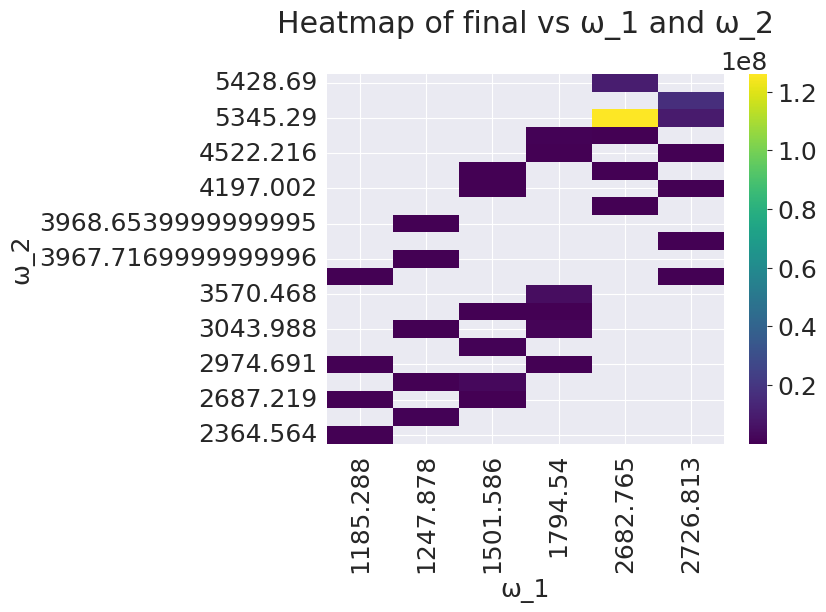

In [56]:
import seaborn as sns

heatmap_data = result_later.pivot(index='ω_2', columns='ω_1', values='final')

sns.heatmap(heatmap_data, cmap='viridis')
plt.gca().invert_yaxis()

plt.xlabel('ω_1')
plt.ylabel('ω_2')
plt.title('Heatmap of final vs ω_1 and ω_2')
plt.show()

## Heatmap plotly - resonances

In [57]:
import plotly.express as px
import plotly.graph_objects as go

# Reverse the ω_2 axis by sorting the DataFrame
heatmap_data = result_later.pivot(index='ω_2', columns='ω_1', values='final')

# Ensure ω_2 values are sorted in descending order for the reversed axis
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index, reverse=True))

fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=heatmap_data.columns,
    y=heatmap_data.index,
    colorscale='viridis',
    colorbar=dict(title='final')
))

fig.update_layout(
    xaxis_title='ω_1',
    yaxis_title='ω_2',
    title='Heatmap of final vs ω_1 and ω_2',
    width=900, height=800
)

fig.show()

## Scatter plot plotly - resonances

In [58]:
import plotly.express as px
formatted_df1 = result_later.copy()
print(formatted_df1.columns)
# formatted_df['final'] = np.log10(result_later['final']) if result_later[result_later['final']]>1e4 else 0.
# formatted_df['final'] = formatted_df['final'].apply(lambda x: 0 if x < 1e4 else np.log(x))

fig = px.scatter(formatted_df1[(formatted_df1['final']>2.9e5)
                              # &(formatted_df['final']<1e8)
                 ], 
                 x='ω_1', 
                 y='ω_2', 
                 color='final', 
                 color_continuous_scale='viridis', 
                 title='Scatter Plot of final vs ω_1 and ω_2',
                 width=900, height=800,
                 hover_data={'final':':.2e', 'abc_tuples': True, #'a': True, 'b': True, 'c': True
                             },
                 range_color=(0.1e5,1.8e8))

fig.update_layout(
    xaxis_title='ω_1',
    yaxis_title='ω_2',
    coloraxis_colorbar=dict(title='final'),
    plot_bgcolor='aliceblue'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightPink')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightPink')
fig.update_coloraxes(colorbar_tickformat = '.2e'.format())

fig.show()

Index(['ω_1', 'ω_2', 'gamma_mn', 'final', 'abc_tuples'], dtype='object')


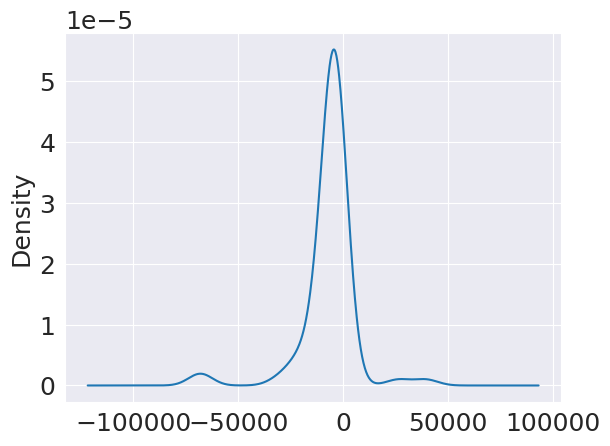

In [59]:
bax0 = result[['ii', 'a', 'b', 'c', 'ω_1', 'ω_2', 'FR1', 'FR2', 'SoF', 'Fermi', 'DoR', 'avrg_g', 'F_abc', 'gamma_mn', 'abs']]['Fermi'].plot(kind='kde')

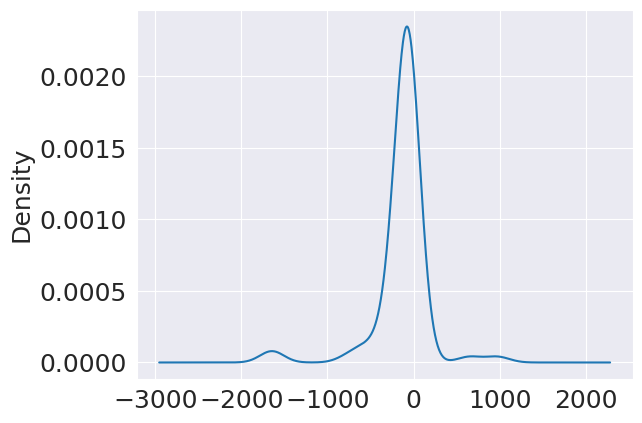

In [60]:
ax = result[['ii', 'a', 'b', 'c', 'ω_1', 'ω_2', 'FR1', 'FR2', 'SoF', 'Fermi', 'DoR', 'avrg_g', 'F_abc', 'gamma_mn', 'abs']]['SoF'].plot(kind='kde')

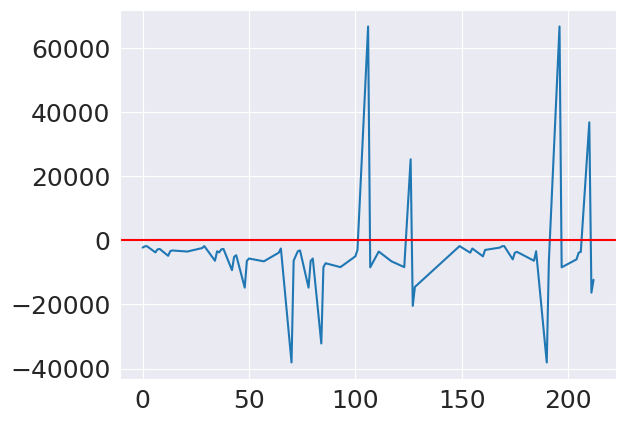

In [38]:
ax1 = result[['ii', 'a', 'b', 'c', 'ω_1', 'ω_2', 'FR1', 'FR2', 'SoF', 'Fermi', 'DoR', 'avrg_g', 'F_abc', 'gamma_mn', 'abs']]['Fermi'].plot.line()
ax1.axhline(0, c='r')

In [39]:
import plotly.express as px
fig = px.line(result, y="Fermi", width=1500, height=1000, hover_data=["a", "b", "c", 'ω_1', 'ω_2'])
fig.show()

In [ ]:
# print(result[['ii', 'a', 'b', 'c', 'ω_a', 'ω_b', 'ω_c', 'ω_1', 'ω_2', 'avrg_g', 'F_abc', 'resonances', 'finalI']][(result['ω_1']==1247.878)&(result['ω_2']==2491.481)].sum())
# print(result[['ii', 'a', 'b', 'c', 'ω_a', 'ω_b', 'ω_c', 'ω_1', 'ω_2', 'avrg_g', 'F_abc', 'DoR', 'gamma_mn']][(result['ω_1']==1247.878)&(result['ω_2']==2491.481)]['gamma_mn'].sum())
# print( 4.242703e+04 )
# print(result[['ii',  'ω_1', 'ω_2', 'avrg_g', 'F_abc', 'SoF', 'DoR', 'gamma_mn']][(result['a']==0)&(result['b']==0)&(result['c']==0)])

In [ ]:
# dfMech['abs(FR1)'] = abs(dfMech['FR1'])
# dfMech['abs(FR2)'] = abs(dfMech['FR2'])

# dfMech['finalI'] = dfMech['finalI'].map('{:.4g}'.format)
# forPrint = dfMech.drop(['abs(FR1)', 'abs(FR2)', 'res1', 'res2', 'FR1', 'FR2'], axis=1)
# pairs = forPrint[['ω_1', 'ω_2']]
# selected_columns = dfMech[['ii', 'ω_1', 'ω_2', 'gamma_mn']]
# unique_pairs = selected_columns.drop_duplicates(subset=['ω_1', 'ω_2']).reset_index(drop=True)



# print('------')
# print(unique_pairs.sort_values(by=['ω_1', 'ω_2']))
# print('Total', dfMech['finalI'].sum())
# print('---------------')

# plt.bar(range(len(dfMech['(sum/prod)_FR'])), dfMech['(sum/prod)_FR'], 1.)
# plt.title(f'(sum/prod)_FR: Resonances: {dfMech['res1'].iloc[0]} | Sum of 2: {dfMech['res2'].iloc[0]}')
# plt.show()

# plt.bar(range(len(dfMech['avrg_g'])), dfMech['avrg_g'], 1.)
# plt.title(f'avrg_g: Resonances: {dfMech['res1'].iloc[0]} | Sum of 2: {dfMech['res2'].iloc[0]}')
# plt.show()



# w_all = computedSpectrum.all_states_harmonic if vib_levels_harmonic else computedSpectrum.all_states
# 
# mechanical_terms_str = [(('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')),
#                         (('c,a', 'zero,a'), ('a+b,c', 'b+c,a')),
#                         (('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')),
#                         (('b,a', 'zero,a'), ('b,a+b', 'a,zero')),
#                         (('b,a', 'zero,a'), ('a,a+b', 'b,zero')),
#                         (('b,a', 'zero,a'), ('b,a+b', 'a,zero'))]
# yo = spectrum.generate_resonances_functions(*mechanical_terms_str[0])
# w_all[('zero',)] = 0.
# resonances = []
# 
# for idx, row in dfMech.iterrows():
#     r = yo(w_all, row['ω_1'], row['ω_2'], Gamma, (row['a'], row['b'], row['c']))
#     resonances.append(r)
# 
# dfMech['resonances'] = resonances

### 5. Copy of the second half of 3 - _Full dataframe_

In [20]:
pd.options.mode.chained_assignment = None
pd.set_option('display.float_format', '{:.2g}'.format)

for dfMech in dfs4terms_mech:
    # to see how many resonances there could be - depends on the number of combinations of a,b,c
    print('Original length', len(dfMech))
    # print the expressions for resonances of this term
    print('Resonances:', dfMech['res1'].iloc[0], '\nSum of 2:', dfMech['res2'].iloc[0])
    if rec_cm:
        # filters: non-zero F_abc; within the window selected above
        dfMech = dfMech[(dfMech['F_abc'] != 0.) & 
                        (abs(dfMech['ω_2']) > omega2[0]) & 
                        (abs(dfMech['ω_2']) < omega2[-1]) & 
                        (abs(dfMech['ω_1']) > omega1[0]) & 
                        (abs(dfMech['ω_1']) < omega1[-1])]
    else:
        dfMech = dfMech[(dfMech['F_abc'] != 0.) & 
                    (abs(dfMech['ω_2']) > spectrum.rec_cm2rec_s(omega2[0])) & 
                    (abs(dfMech['ω_2']) < spectrum.rec_cm2rec_s(omega2[-1])) & 
                    (abs(dfMech['ω_1']) > spectrum.rec_cm2rec_s(omega1[0])) & 
                    (abs(dfMech['ω_1']) < spectrum.rec_cm2rec_s(omega1[-1]))]
    
    # adding a column for the sum term in product
    if rec_cm:
        dfMech['(sum/prod)_FR'] = (spectrum.rec_cm2rec_s(dfMech['FR1']+dfMech['FR2'])/spectrum.rec_cm2rec_s(dfMech['FR1'])/spectrum.rec_cm2rec_s(dfMech['FR2']))
    else:
        dfMech['(sum/prod)_FR'] = ((dfMech['FR1']+dfMech['FR2'])/dfMech['FR1']/dfMech['FR2'])
        
    dfMech['prod_FR'] = abs(dfMech['FR1']*dfMech['FR2'])
    # dfMech['finalI'] = np.log10(dfMech['avrg_g']*dfMech['F_abc']*dfMech['(sum/prod)_FR']/((-1)*1j*spectrum.rec_cm2rec_s(broad_factor_rc))**2/computedSpectrum.tensor_3d.T[dfMech['a'], dfMech['b'], dfMech['c']])
    dfMech['finalI'] = dfMech['avrg_g']*dfMech['F_abc']*dfMech['(sum/prod)_FR']/((-1)*1j*spectrum.rec_cm2rec_s(broad_factor_rc))**2/computedSpectrum.tensor_3d.T[dfMech['a'], dfMech['b'], dfMech['c']]
    dfMech = dfMech[abs(np.real(dfMech['finalI'])) > 10**3]
    dfMech['abs(FR1)'] = abs(dfMech['FR1'])
    dfMech['abs(FR2)'] = abs(dfMech['FR2'])
    # small1 = dfMech[(dfMech['F_abc'] != 0.)&(dfMech['(sum/prod)_FR']!=0.)].nsmallest(5, 'prod_FR')

    print('New length', len(dfMech.drop(['abs(FR1)', 'abs(FR2)', 'res1', 'res2'], axis=1)))
    print(dfMech.drop(['abs(FR1)', 'abs(FR2)', 'res1', 'res2', 'prod_FR'], axis=1))
    # print('Total', dfMech['finalI'].sum())
    print('---------------')
    
    # plt.bar(range(len(dfMech['(sum/prod)_FR'])), dfMech['(sum/prod)_FR'], 1.)
    # plt.title(f'(sum/prod)_FR: Resonances: {dfMech['res1'].iloc[0]} | Sum of 2: {dfMech['res2'].iloc[0]}')
    # plt.show()

    # plt.bar(range(len(dfMech['avrg_g'])), dfMech['avrg_g'], 1.)
    # plt.title(f'avrg_g: Resonances: {dfMech['res1'].iloc[0]} | Sum of 2: {dfMech['res2'].iloc[0]}')
    # plt.show()

Original length 216
Resonances: a+b,a__zero,a 
Sum of 2: a+b+c,zero__c,a+b
New length 0
Empty DataFrame
Columns: [ii, a, b, c, ω_a, ω_b, ω_c, ω_2-ω_1, ω_1, ω_2, FR1, FR2, F_abc, avrg_g, (sum/prod)_FR, finalI]
Index: []
---------------


## Plans and expectations

1. [+] Compute resonance grid points separately in the dataframe and get from the spectrum calculation - should be the same numbers. Need to make the same exactly the calculation of the intensity. 
2. []  